In [241]:
!ls

submission_20260403_123902.csv


In [286]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import fbeta_score
from datetime import datetime
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
import torch
import torch.nn as nn
import torch.optim as optim

In [243]:
sample_df = pd.read_csv("/kaggle/input/competitions/super-ai-engineer-ss-6-heart-disease-prediction/sample_submission.csv")
test_df = pd.read_csv("/kaggle/input/competitions/super-ai-engineer-ss-6-heart-disease-prediction/test.csv")
train_df = pd.read_csv("/kaggle/input/competitions/super-ai-engineer-ss-6-heart-disease-prediction/train.csv")

In [244]:
sample_df

,ID,History of HeartDisease or Attack
0,test_000001,No
1,test_000002,No
2,test_000003,No
3,test_000004,NaN
4,test_000005,NaN
...,...,...
74356,test_074357,NaN
74357,test_074358,NaN
74358,test_074359,NaN
74359,test_074360,NaN


In [245]:
train_df

,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,train_000001,No,Yes,Yes,Yes,40.68,Yes,No,No,No,No,Yes,No,Very Poor,Yes,Female,High school graduate,"$15,000 to less than $20,000",64,Yes
1,train_000002,No,No,No,No,24.36,Yes,No,No,Yes,No,No,Yes,Fair,No,Female,College graduate,"Less than $10,000",50,No
2,train_000003,No,Yes,Yes,Yes,27.33,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,High school graduate,"$75,000 or more",61,Yes
3,train_000004,No,Yes,No,Yes,27.01,No,No,No,Yes,No,Yes,No,Good,No,Female,Some high school,"$35,000 to less than $50,000",74,Yes
4,train_000005,NaN,Yes,Yes,Yes,34.56,Yes,No,No,Yes,No,Yes,Yes,Very Poor,Yes,Male,Some high school,"$15,000 to less than $20,000",98,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223079,train_223080,No,No,No,Yes,28.20,No,No,No,No,No,Yes,No,Excellent,No,Female,College graduate,"$25,000 to less than $35,000",34,Yes
223080,train_223081,No,Yes,Yes,Yes,45.01,No,No,No,No,No,Yes,No,Fair,No,Male,College graduate,"$50,000 to less than $75,000",43,Yes
223081,train_223082,No,Yes,Yes,Yes,18.94,No,No,Yes,No,No,Yes,No,Poor,Yes,Female,Elementary,"$20,000 to less than $25,000",72,No
223082,train_223083,No,No,No,Yes,29.29,No,No,No,Yes,No,Yes,No,Excellent,No,Female,Some college or technical school,"($10,000 to less than $15,000",28,Yes


In [246]:
test_df

,ID,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,test_000001,Yes,Yes,Yes,24.84,No,No,No,Yes,No,Yes,No,Good,No,Female,Some college or technical school,"$20,000 to less than $25,000",71,Yes
1,test_000002,Yes,No,Yes,29.08,Yes,No,No,No,No,Yes,No,Fair,No,Female,College graduate,"$50,000 to less than $75,000",61,No
2,test_000003,Yes,Yes,Yes,35.23,Yes,No,No,No,No,Yes,No,Fair,Yes,Female,Some college or technical school,"Less than $10,000",67,Yes
3,test_000004,No,No,Yes,24.78,Yes,No,No,No,No,Yes,No,Fair,No,Female,Some college or technical school,"$50,000 to less than $75,000",50,Yes
4,test_000005,No,No,Yes,27.57,Yes,No,No,No,No,Yes,No,Fair,No,Male,Some college or technical school,"$25,000 to less than $35,000",40,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74356,test_074357,Yes,No,Yes,22.85,No,No,No,No,No,Yes,No,Fair,No,Female,Some college or technical school,"($10,000 to less than $15,000",47,Yes
74357,test_074358,Yes,Yes,Yes,28.27,Yes,No,No,No,No,Yes,No,Fair,No,Female,High school graduate,"$50,000 to less than $75,000",71,Yes
74358,test_074359,Yes,Yes,Yes,25.88,No,No,Yes,No,No,Yes,No,Very Poor,Yes,Female,College graduate,"$20,000 to less than $25,000",90,Yes
74359,test_074360,Yes,Yes,Yes,23.74,No,Yes,No,No,No,Yes,Yes,Poor,No,Male,Some high school,"($10,000 to less than $15,000",59,No


In [247]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223084 entries, 0 to 223083
Data columns (total 20 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      223084 non-null  object 
 1   History of HeartDisease or Attack       221390 non-null  object 
 2   High Blood Pressure                     223084 non-null  object 
 3   Told High Cholesterol                   190898 non-null  object 
 4   Cholesterol Checked                     223084 non-null  object 
 5   Body Mass Index                         211302 non-null  float64
 6   Smoked 100+ Cigarettes                  223083 non-null  object 
 7   Diagnosed Stroke                        223084 non-null  object 
 8   Diagnosed Diabetes                      223081 non-null  object 
 9   Leisure Physical Activity               223084 non-null  object 
 10  Heavy Alcohol Consumption               2230

In [248]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74361 entries, 0 to 74360
Data columns (total 19 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   ID                                      74361 non-null  object 
 1   High Blood Pressure                     74361 non-null  object 
 2   Told High Cholesterol                   74361 non-null  object 
 3   Cholesterol Checked                     74361 non-null  object 
 4   Body Mass Index                         74361 non-null  float64
 5   Smoked 100+ Cigarettes                  74361 non-null  object 
 6   Diagnosed Stroke                        74361 non-null  object 
 7   Diagnosed Diabetes                      74361 non-null  object 
 8   Leisure Physical Activity               74361 non-null  object 
 9   Heavy Alcohol Consumption               74361 non-null  object 
 10  Health Care Coverage                    74361 non-null  ob

In [249]:
train_df.columns

Index(['ID', 'History of HeartDisease or Attack', 'High Blood Pressure',
       'Told High Cholesterol', 'Cholesterol Checked', 'Body Mass Index',
       'Smoked 100+ Cigarettes', 'Diagnosed Stroke', 'Diagnosed Diabetes',
       'Leisure Physical Activity', 'Heavy Alcohol Consumption',
       'Health Care Coverage', 'Doctor Visit Cost Barrier', 'General Health',
       'Difficulty Walking', 'Sex', 'Education Level', 'Income Level', 'Age',
       'Vegetable or Fruit Intake (1+ per Day)'],
      dtype='object')

In [250]:
for i in train_df.columns:
    if i == 'ID':
        continue
    print(i, ':', train_df[i].unique())

History of HeartDisease or Attack : ['No' nan 'Yes']
High Blood Pressure : ['Yes' 'No']
Told High Cholesterol : ['Yes' 'No' nan]
Cholesterol Checked : ['Yes' 'No']
Body Mass Index : [40.68 24.36 27.33 ... 60.75 14.73 60.36]
Smoked 100+ Cigarettes : ['Yes' 'No' nan]
Diagnosed Stroke : ['No' 'Yes']
Diagnosed Diabetes : ['No' 'Yes' nan]
Leisure Physical Activity : ['No' 'Yes']
Heavy Alcohol Consumption : ['No' 'Yes']
Health Care Coverage : ['Yes' 'No']
Doctor Visit Cost Barrier : ['No' 'Yes' nan]
General Health : ['Very Poor' 'Fair' 'Good' 'Poor' 'Excellent' nan]
Difficulty Walking : ['Yes' 'No' nan]
Sex : ['Female' 'Male']
Education Level : ['High school graduate' 'College graduate' 'Some high school'
 'Some college or technical school' 'Elementary' 'Never attended school']
Income Level : ['$15,000 to less than $20,000' 'Less than $10,000' '$75,000 or more'
 '$35,000 to less than $50,000' '$20,000 to less than $25,000'
 '($10,000 to less than $15,000' '$50,000 to less than $75,000'
 '$25

In [251]:
for col in train_df.columns:
    if train_df[col].dtype == 'object':  
        train_df[col] = train_df[col].fillna(method='ffill').fillna(method='bfill')
    else:
        train_df[col] = train_df[col].fillna(train_df[col].mean())

/tmp/ipykernel_55/1366302837.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df[col] = train_df[col].fillna(method='ffill').fillna(method='bfill')


In [252]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223084 entries, 0 to 223083
Data columns (total 20 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      223084 non-null  object 
 1   History of HeartDisease or Attack       223084 non-null  object 
 2   High Blood Pressure                     223084 non-null  object 
 3   Told High Cholesterol                   223084 non-null  object 
 4   Cholesterol Checked                     223084 non-null  object 
 5   Body Mass Index                         223084 non-null  float64
 6   Smoked 100+ Cigarettes                  223084 non-null  object 
 7   Diagnosed Stroke                        223084 non-null  object 
 8   Diagnosed Diabetes                      223084 non-null  object 
 9   Leisure Physical Activity               223084 non-null  object 
 10  Heavy Alcohol Consumption               2230

In [253]:
train_df

,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,train_000001,No,Yes,Yes,Yes,40.68,Yes,No,No,No,No,Yes,No,Very Poor,Yes,Female,High school graduate,"$15,000 to less than $20,000",64,Yes
1,train_000002,No,No,No,No,24.36,Yes,No,No,Yes,No,No,Yes,Fair,No,Female,College graduate,"Less than $10,000",50,No
2,train_000003,No,Yes,Yes,Yes,27.33,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,High school graduate,"$75,000 or more",61,Yes
3,train_000004,No,Yes,No,Yes,27.01,No,No,No,Yes,No,Yes,No,Good,No,Female,Some high school,"$35,000 to less than $50,000",74,Yes
4,train_000005,No,Yes,Yes,Yes,34.56,Yes,No,No,Yes,No,Yes,Yes,Very Poor,Yes,Male,Some high school,"$15,000 to less than $20,000",98,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223079,train_223080,No,No,No,Yes,28.20,No,No,No,No,No,Yes,No,Excellent,No,Female,College graduate,"$25,000 to less than $35,000",34,Yes
223080,train_223081,No,Yes,Yes,Yes,45.01,No,No,No,No,No,Yes,No,Fair,No,Male,College graduate,"$50,000 to less than $75,000",43,Yes
223081,train_223082,No,Yes,Yes,Yes,18.94,No,No,Yes,No,No,Yes,No,Poor,Yes,Female,Elementary,"$20,000 to less than $25,000",72,No
223082,train_223083,No,No,No,Yes,29.29,No,No,No,Yes,No,Yes,No,Excellent,No,Female,Some college or technical school,"($10,000 to less than $15,000",28,Yes


In [254]:
for i in train_df.columns:
    if i == 'ID':
        continue
    print(i, ':', train_df[i].unique())

History of HeartDisease or Attack : ['No' 'Yes']
High Blood Pressure : ['Yes' 'No']
Told High Cholesterol : ['Yes' 'No']
Cholesterol Checked : ['Yes' 'No']
Body Mass Index : [40.68 24.36 27.33 ... 60.75 14.73 60.36]
Smoked 100+ Cigarettes : ['Yes' 'No']
Diagnosed Stroke : ['No' 'Yes']
Diagnosed Diabetes : ['No' 'Yes']
Leisure Physical Activity : ['No' 'Yes']
Heavy Alcohol Consumption : ['No' 'Yes']
Health Care Coverage : ['Yes' 'No']
Doctor Visit Cost Barrier : ['No' 'Yes']
General Health : ['Very Poor' 'Fair' 'Good' 'Poor' 'Excellent']
Difficulty Walking : ['Yes' 'No']
Sex : ['Female' 'Male']
Education Level : ['High school graduate' 'College graduate' 'Some high school'
 'Some college or technical school' 'Elementary' 'Never attended school']
Income Level : ['$15,000 to less than $20,000' 'Less than $10,000' '$75,000 or more'
 '$35,000 to less than $50,000' '$20,000 to less than $25,000'
 '($10,000 to less than $15,000' '$50,000 to less than $75,000'
 '$25,000 to less than $35,000']


In [255]:
test_df['History of HeartDisease or Attack'] = 'No'
test_df['History of HeartDisease or Attack']

0        No
1        No
2        No
3        No
4        No
         ..
74356    No
74357    No
74358    No
74359    No
74360    No
Name: History of HeartDisease or Attack, Length: 74361, dtype: object

In [256]:
binary_cols = [
    'History of HeartDisease or Attack',
    'High Blood Pressure',
    'Told High Cholesterol',
    'Cholesterol Checked',
    'Smoked 100+ Cigarettes',
    'Diagnosed Stroke',
    'Diagnosed Diabetes',
    'Leisure Physical Activity',
    'Heavy Alcohol Consumption',
    'Health Care Coverage',
    'Doctor Visit Cost Barrier',
    'Difficulty Walking',
    'Vegetable or Fruit Intake (1+ per Day)'
]

for col in binary_cols:
    train_df[col] = train_df[col].map({'No': 0, 'Yes': 1})
    test_df[col] = test_df[col].map({'No': 0, 'Yes': 1})

In [257]:
train_df['Sex'] = train_df['Sex'].map({'Female': 0, 'Male': 1})
test_df['Sex'] = test_df['Sex'].map({'Female': 0, 'Male': 1})

In [258]:
health_map = {
    'Very Poor': 0,
    'Poor': 1,
    'Fair': 2,
    'Good': 3,
    'Excellent': 4
}
train_df['General Health'] = train_df['General Health'].map(health_map)
test_df['General Health'] = test_df['General Health'].map(health_map)

In [259]:
edu_map = {
    'Never attended school': 0,
    'Elementary': 1,
    'Some high school': 2,
    'High school graduate': 3,
    'Some college or technical school': 4,
    'College graduate': 5
}
train_df['Education Level'] = train_df['Education Level'].map(edu_map)
test_df['Education Level'] = test_df['Education Level'].map(edu_map)

In [260]:
income_map = {
    'Less than $10,000': 0,
    '($10,000 to less than $15,000': 1,
    '$15,000 to less than $20,000': 2,
    '$20,000 to less than $25,000': 3,
    '$25,000 to less than $35,000': 4,
    '$35,000 to less than $50,000': 5,
    '$50,000 to less than $75,000': 6,
    '$75,000 or more': 7
}
train_df['Income Level'] = train_df['Income Level'].map(income_map)
test_df['Income Level'] = test_df['Income Level'].map(income_map)

In [261]:
print(train_df.dtypes)

ID                                         object
History of HeartDisease or Attack           int64
High Blood Pressure                         int64
Told High Cholesterol                       int64
Cholesterol Checked                         int64
Body Mass Index                           float64
Smoked 100+ Cigarettes                      int64
Diagnosed Stroke                            int64
Diagnosed Diabetes                          int64
Leisure Physical Activity                   int64
Heavy Alcohol Consumption                   int64
Health Care Coverage                        int64
Doctor Visit Cost Barrier                   int64
General Health                              int64
Difficulty Walking                          int64
Sex                                         int64
Education Level                             int64
Income Level                                int64
Age                                         int64
Vegetable or Fruit Intake (1+ per Day)      int64


In [262]:
for i in train_df.columns:
    if i == 'ID':
        continue
    print(i, ':', train_df[i].unique())

History of HeartDisease or Attack : [0 1]
High Blood Pressure : [1 0]
Told High Cholesterol : [1 0]
Cholesterol Checked : [1 0]
Body Mass Index : [40.68 24.36 27.33 ... 60.75 14.73 60.36]
Smoked 100+ Cigarettes : [1 0]
Diagnosed Stroke : [0 1]
Diagnosed Diabetes : [0 1]
Leisure Physical Activity : [0 1]
Heavy Alcohol Consumption : [0 1]
Health Care Coverage : [1 0]
Doctor Visit Cost Barrier : [0 1]
General Health : [0 2 3 1 4]
Difficulty Walking : [1 0]
Sex : [0 1]
Education Level : [3 5 2 4 1 0]
Income Level : [2 0 7 5 3 1 6 4]
Age : [ 64  50  61  74  98  67  72  59  90  53  65  70  35  46  54  29  32  37
  75  77  48  89  80  42  31  76  60  79  63  51  57  52  66  68  69  71
  47  73  97  18  49  55  39  82  88  62  43  30  56  34  78  58  40  20
  86  41  93  28 100  94  38  19  84  33  92  36  44  45  85  21  96  95
  27  24  99  87  83  23  26  25  91  22  81]
Vegetable or Fruit Intake (1+ per Day) : [1 0]


In [263]:
for i in test_df.columns:
    if i == 'ID':
        continue
    print(i, ':', test_df[i].unique())

High Blood Pressure : [1 0]
Told High Cholesterol : [1 0]
Cholesterol Checked : [1 0]
Body Mass Index : [24.84 29.08 35.23 ... 14.28 48.69 49.19]
Smoked 100+ Cigarettes : [0 1]
Diagnosed Stroke : [0 1]
Diagnosed Diabetes : [0 1]
Leisure Physical Activity : [1 0]
Heavy Alcohol Consumption : [0 1]
Health Care Coverage : [1 0]
Doctor Visit Cost Barrier : [0 1]
General Health : [3 2 4 0 1]
Difficulty Walking : [0 1]
Sex : [0 1]
Education Level : [4 5 3 2 1 0]
Income Level : [3 6 0 4 5 2 1 7]
Age : [ 71  61  67  50  40  60  94  70  77  39  87  59  72  69  65  37  78  57
  75  55  43  97  32  76  62  68  35  49  53  52  92  56  63  54  82  48
  79  88  96  85  44  74  64  66  47  81  86  93  73  30  91  42  89  45
  90  58  83 100  41  98  51  31  95  84  38  23  99  18  27  80  46  29
  22  36  28  21  25  34  20  26  19  24  33]
Vegetable or Fruit Intake (1+ per Day) : [1 0]
History of HeartDisease or Attack : [0]


In [264]:
train_df.describe()

,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
count,223084.000000,223084.000000,223084.000000,223084.000000,223084.000000,223084.000000,223084.00000,223084.000000,223084.000000,223084.000000,223084.000000,223084.000000,223084.000000,223084.000000,223084.000000,223084.000000,223084.000000,223084.000000,223084.000000
mean,0.081615,0.388813,0.417090,0.823833,28.189817,0.435688,0.03656,0.132784,0.748489,0.058059,0.926700,0.100966,2.495038,0.158474,0.434316,3.984400,4.905457,54.739717,0.873070
std,0.273778,0.487482,0.493079,0.380963,6.509428,0.495848,0.18768,0.339342,0.433882,0.233855,0.260628,0.301285,1.063035,0.365186,0.495668,1.013506,2.127799,17.795140,0.332895
min,0.000000,0.000000,0.000000,0.000000,11.210000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,24.070000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,3.000000,3.000000,42.000000,1.000000
50%,0.000000,0.000000,0.000000,1.000000,27.430000,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,4.000000,5.000000,56.000000,1.000000
75%,0.000000,1.000000,1.000000,1.000000,30.800000,1.000000,0.00000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.000000,1.000000,5.000000,7.000000,67.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,98.630000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,5.000000,7.000000,100.000000,1.000000


In [265]:
test_df.describe()

,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day),History of HeartDisease or Attack
count,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000,74361.0
mean,0.430387,0.425976,0.962938,28.402408,0.442544,0.040519,0.145775,0.755665,0.056051,0.951668,0.083982,2.491292,0.167830,0.441253,4.053065,5.061968,57.722112,0.882869,0.0
std,0.495134,0.494493,0.188916,6.598611,0.496691,0.197173,0.352883,0.429695,0.230022,0.214468,0.277363,1.067281,0.373718,0.496540,0.982708,2.065198,16.449871,0.321579,0.0
min,0.000000,0.000000,0.000000,11.490000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.0
25%,0.000000,0.000000,1.000000,24.110000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,3.000000,4.000000,47.000000,1.000000,0.0
50%,0.000000,0.000000,1.000000,27.300000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,4.000000,6.000000,59.000000,1.000000,0.0
75%,1.000000,1.000000,1.000000,31.350000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.000000,1.000000,5.000000,7.000000,69.000000,1.000000,0.0
max,1.000000,1.000000,1.000000,96.950000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,5.000000,7.000000,100.000000,1.000000,0.0


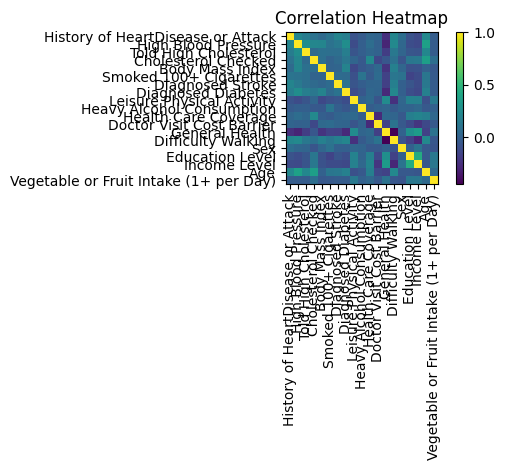

History of HeartDisease or Attack         1.000000
Age                                       0.229611
High Blood Pressure                       0.217172
Difficulty Walking                        0.212505
Diagnosed Stroke                          0.204609
Diagnosed Diabetes                        0.174202
Told High Cholesterol                     0.164206
Smoked 100+ Cigarettes                    0.110138
Cholesterol Checked                       0.101794
Sex                                       0.075559
Body Mass Index                           0.055519
Health Care Coverage                      0.034399
Doctor Visit Cost Barrier                 0.019765
Vegetable or Fruit Intake (1+ per Day)   -0.019280
Heavy Alcohol Consumption                -0.028081
Leisure Physical Activity                -0.076445
Education Level                          -0.076865
Income Level                             -0.116314
General Health                           -0.244669
Name: History of HeartDisease o

In [282]:
# Combine features + target
df_corr = train_df.drop(columns=['ID'])

# Compute correlation
corr = df_corr.corr()

# Plot heatmap (no seaborn)
plt.figure()
plt.imshow(corr)
plt.colorbar()

# Add labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

target_corr = corr['History of HeartDisease or Attack'].sort_values(ascending=False)
print(target_corr)

In [288]:
# =========================
# 1. Prepare data
# =========================
X = train_df.drop(columns=['ID', 'History of HeartDisease or Attack']).values
y = train_df['History of HeartDisease or Attack'].values

X_test = test_df.drop(columns=['ID', 'History of HeartDisease or Attack'], errors='ignore').values

# =========================
# 2. Train / validation split
# =========================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# =========================
# 3. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# =========================
# 4. Model
# =========================
class Model(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.3),
            
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.BatchNorm1d(16),
            nn.Dropout(0.3),
            
            nn.Linear(16, 1)
        )
    
    def forward(self, x):
        return self.net(x)

model = Model(X_train.shape[1])

# =========================
# 5. Loss (handle imbalance)
# =========================
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=0.001)

# =========================
# 6. Training
# =========================
for epoch in range(500):
    model.train()
    
    optimizer.zero_grad()
    outputs = model(X_train).squeeze()
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

# =========================
# 7. Validation + threshold tuning
# =========================
model.eval()
with torch.no_grad():
    val_logits = model(X_val).squeeze()
    val_probs = torch.sigmoid(val_logits).numpy()

best_f2 = 0
best_thresh = 0.5

for t in np.linspace(0.05, 0.4, 100):
    preds = (val_probs >= t).astype(int)
    f2 = fbeta_score(y_val, preds, beta=2)
    if f2 > best_f2:
        best_f2 = f2
        best_thresh = t

print("Best F2:", best_f2)
print("Best Threshold:", best_thresh)

# =========================
# 8. Predict test
# =========================
with torch.no_grad():
    test_logits = model(X_test_tensor).squeeze()
    test_probs = torch.sigmoid(test_logits).numpy()

test_preds = (test_probs >= best_thresh).astype(int)
test_labels = pd.Series(test_preds).map({0: 'No', 1: 'Yes'})

# =========================
# 9. Submission
# =========================
submission = pd.DataFrame({
    'ID': test_df['ID'],
    'History of HeartDisease or Attack': test_labels
})

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
filename = f'submission_{timestamp}.csv'

submission.to_csv(filename, index=False)

print(f"Saved: {filename}")

Best F2: 0.5097521907095072
Best Threshold: 0.4
Saved: submission_20260403_130422.csv
